In [1]:
import uproot
import pandas as pd
import numpy as np
import glob


In [2]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [19]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_Kspip_loose_v7_250228"
cm_elements = ["Kshp_13_had_4S_off_v1", "Kshp_13_had_4S_v3", "Kshp_23_had_4S_off_v1", "Kshp_23_had_4S_v1", "Kshp_23_had_5Sscan_10657_v1", "Kshp_23_had_5Sscan_10706_v1",\
               "Kshp_23_had_5Sscan_10751_v1", "Kshp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"
file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/apply_bdt/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','BDT']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [20]:
len(file_list)

16

In [4]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [5]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,1.338832e+06,1.338832e+06,1.338832e+06,1.338832e+06,1.338832e+06,1.338832e+06
mean,1.875998e+00,1.127482e-01,3.535969e-01,1.873409e+00,-7.255578e-03,4.027212e-01
std,1.338290e-01,5.461064e-01,4.882333e-01,1.096874e+00,9.999741e-01,2.917047e-01
min,1.600000e+00,-9.999745e-01,-9.192500e-01,4.000001e-01,-1.000000e+00,1.349899e-04
25%,1.777165e+00,-3.804084e-01,-7.117397e-02,8.605303e-01,-1.000000e+00,1.561863e-01
50%,1.891148e+00,1.384971e-01,4.824942e-01,1.780495e+00,-1.000000e+00,3.289861e-01
75%,1.972843e+00,6.166554e-01,8.037469e-01,2.666615e+00,1.000000e+00,6.268654e-01
max,2.100000e+00,1.000000e+00,9.809135e-01,1.425163e+01,1.000000e+00,9.980702e-01


In [6]:
df_proc13 = df_proc13.query('Dp_M> 1.9 & Dp_M<2.03')


In [7]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,485731.000000,485731.000000,485731.000000,485731.000000,485731.000000,485731.000000
mean,1.966002,0.110694,0.348892,1.969899,-0.006187,0.454793
std,0.030580,0.548770,0.489231,1.074689,0.999982,0.307437
min,1.900001,-0.999919,-0.900848,0.400011,-1.000000,0.000135
25%,1.948154,-0.382968,-0.083367,1.045227,-1.000000,0.181509
50%,1.967883,0.133825,0.475851,1.878719,-1.000000,0.396641
75%,1.982141,0.615319,0.803791,2.719232,1.000000,0.728648
max,2.030000,0.999996,0.974281,11.718768,1.000000,0.997960


In [8]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
BDT                False
dtype: bool


In [9]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p"
cm_elements = ["MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1", "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1", "MCrd_Ks_mori_off_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/apply_bdt/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','BDT']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [10]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [11]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,6.273428e+06,6.273428e+06,6.273428e+06,6.273428e+06,6.273428e+06,6.273428e+06
mean,1.870496e+00,1.091395e-01,3.608780e-01,1.789925e+00,2.236098e-03,3.881063e-01
std,1.348671e-01,5.369371e-01,4.806287e-01,1.117870e+00,9.999976e-01,2.848309e-01
min,1.600000e+00,-9.999759e-01,-9.184131e-01,4.000000e-01,-1.000000e+00,1.105573e-04
25%,1.766517e+00,-3.690925e-01,-4.529542e-02,7.745699e-01,-1.000000e+00,1.517273e-01
50%,1.886424e+00,1.362831e-01,4.868970e-01,1.582204e+00,1.000000e+00,3.141191e-01
75%,1.970745e+00,5.993761e-01,7.993079e-01,2.599577e+00,1.000000e+00,5.943358e-01
max,2.100000e+00,9.999997e-01,9.808307e-01,3.816544e+01,1.000000e+00,9.981523e-01


In [12]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.9 & Dp_M<2.03')


In [13]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,2.280528e+06,2.280528e+06,2.280528e+06,2.280528e+06,2.280528e+06,2.280528e+06
mean,1.965401e+00,1.024345e-01,3.511594e-01,1.899426e+00,2.861618e-03,4.455225e-01
std,3.005424e-02,5.397387e-01,4.815080e-01,1.091521e+00,9.999961e-01,3.057989e-01
min,1.900000e+00,-9.999395e-01,-9.175247e-01,4.000000e-01,-1.000000e+00,1.307717e-04
25%,1.948806e+00,-3.757707e-01,-6.545985e-02,9.417241e-01,-1.000000e+00,1.751947e-01
50%,1.967601e+00,1.197149e-01,4.713080e-01,1.761120e+00,1.000000e+00,3.832251e-01
75%,1.979442e+00,5.950723e-01,7.954138e-01,2.659426e+00,1.000000e+00,7.153497e-01
max,2.030000e+00,9.999997e-01,9.786391e-01,3.816544e+01,1.000000e+00,9.979625e-01


In [14]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
BDT                False
dtype: bool


In [15]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


/home/jykim/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3378: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  exec(code_obj, self.user_global_ns, self.user_ns)


In [16]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


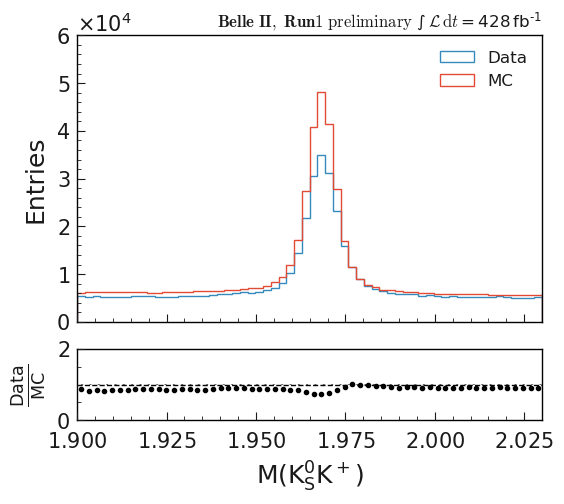

In [17]:
name = "Dp_M"
category = "category"
xlabel = r"$M(K_S^0 K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.9,2.03)

h1 = make_hist(x1, bins=60, range=x_range, weights=1)
h2 = make_hist(x2, bins=60, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{ref_tree}_{name}_no_bdt.png", bbox_inches="tight")

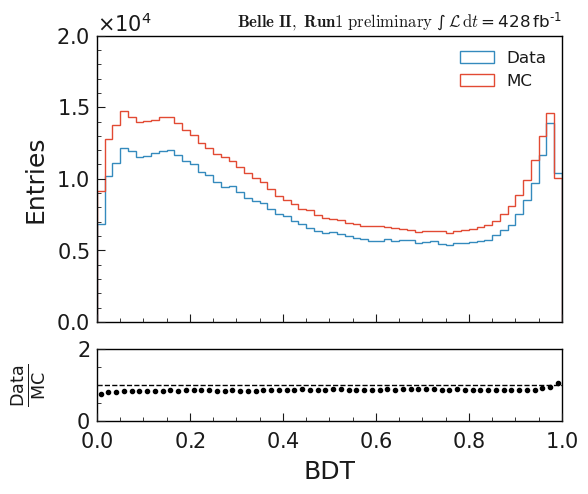

In [18]:
name = "BDT"
category = "category"
xlabel = r"BDT"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (0,1)

h1 = make_hist(x1, bins=60, range=x_range, weights=1)
h2 = make_hist(x2, bins=60, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{ref_tree}_{name}_no_bdt.png", bbox_inches="tight")